# Feature-Based Unsupervised Anomaly Detection Walkthrough

This notebook uses the same single-record vibration dataset as `01_signal_analysis_walkthrough_v2.ipynb`, but keeps anomaly detection focused on interpretable sliding-window features.

The dataset is unlabeled, so every model output is an inspection ranking, not a confirmed fault label. Raw waveform chunk models, neural autoencoders, and spectrogram image classifiers are intentionally excluded because this record is short and produces only a few hundred overlapping windows.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signal_processing_prep.data_loading import load_signal_file
from signal_processing_prep.features import FrequencyBand, SlidingWindowConfig, sliding_window_features
from signal_processing_prep.modeling import (
    run_dbscan_outlier_scores,
    run_isolation_forest,
    run_local_outlier_factor,
    run_one_class_svm,
    run_pca_reconstruction,
    top_anomalies,
    run_robust_z_score,
    run_robust_mahalanobis_distance,
)
from signal_processing_prep.plotting import (
    plot_frequency_spectrum,
    plot_spectrogram_dynamic_range,
    plot_time_signal,
    plot_time_signal_adaptive,
    plot_wavelet_scalogram,
)
from signal_processing_prep.quality import assess_signal_quality
from signal_processing_prep.records import SignalRecord

plt.style.use("default")

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "vibration_anomaly_single_record.csv"
DATA_PATH

WindowsPath('c:/Users/jonas/software_development/signal_processing_prep/data/raw/vibration_anomaly_single_record.csv')

In [3]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        print("Using matplotlib widget backend.")
    except Exception:
        ip.run_line_magic("matplotlib", "inline")
        print("Widget backend unavailable; using inline plots.")

Using matplotlib widget backend.


## 2. Load The Same Dataset

In [4]:
record = load_signal_file(DATA_PATH, signal_column="voltage")

print(record)
print(f"Samples: {record.n_samples:,}")
print(f"Duration: {record.duration_seconds:.2f} s")
print(f"Sampling rate: {record.sampling_rate_hz:.1f} Hz")
print(f"Label: {record.label}")

SignalRecord(values=array([0.01070255, 0.01408059, 0.01657691, ..., 0.01189712, 0.00994643,
       0.010893  ], shape=(240000,)), sampling_rate_hz=20000.000000046613, label=None, name='vibration_anomaly_single_record', metadata={'source_path': 'c:\\Users\\jonas\\software_development\\signal_processing_prep\\data\\raw\\vibration_anomaly_single_record.csv', 'format': 'csv', 'signal_column': 'voltage', 'columns': ['time', 'voltage'], 'time_column': 'time', 'time_start_seconds': 0.0, 'time_end_seconds': 11.99995, 'time_axis_valid': True, 'time_step_median_seconds': 4.999999999988347e-05, 'time_step_jitter_fraction': 3.552713678808781e-11, 'time_gap_count': 0, 'inferred_sampling_rate_hz': 20000.000000046613, 'sampling_rate_source': 'time_column'})
Samples: 240,000
Duration: 12.00 s
Sampling rate: 20000.0 Hz
Label: None


In [5]:
quality = assess_signal_quality(record)
pd.DataFrame([quality.to_dict()])

,record_name,label,n_samples,sampling_rate_hz,duration_seconds,missing_fraction,has_missing_values,max_abs_amplitude,mean,std,...,has_large_amplitude,stationarity_mean_drift,stationarity_std_cv,is_likely_nonstationary,time_step_jitter_fraction,time_gap_count,has_time_axis_irregularity,sampling_rate_mismatch_fraction,has_sampling_rate_mismatch,issues
0,vibration_anomaly_single_record,None,240000,20000.0,12.0,0.0,False,0.061967,0.000038,0.014527,...,False,0.008758,0.050126,False,3.552714e-11,0,False,0.0,False,


## 3. Brief Signal Context

Before scoring windows, inspect the raw signal, global PSD, and spectrogram. These views explain what the feature-based detectors will later rank.

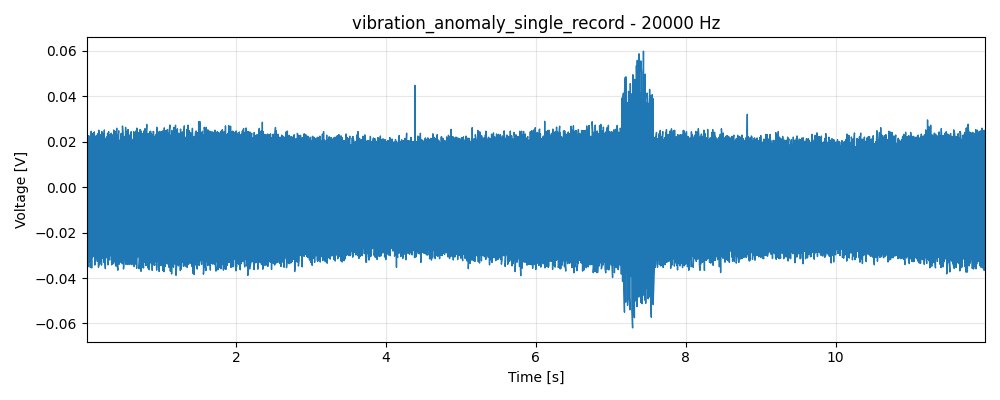

In [6]:
fig, ax = plot_time_signal_adaptive(record, max_points=2000)
ax.set_ylabel("Voltage [V]");

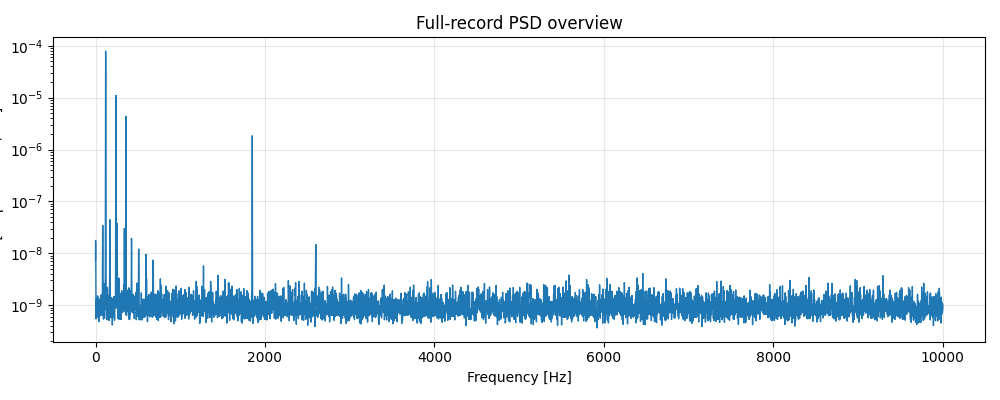

In [7]:
fig, ax = plot_frequency_spectrum(
    record,
    spectrum_type="psd",
    nperseg=4 * 4096,
)
ax.set_title("Full-record PSD overview")
ax.set_yscale("log");

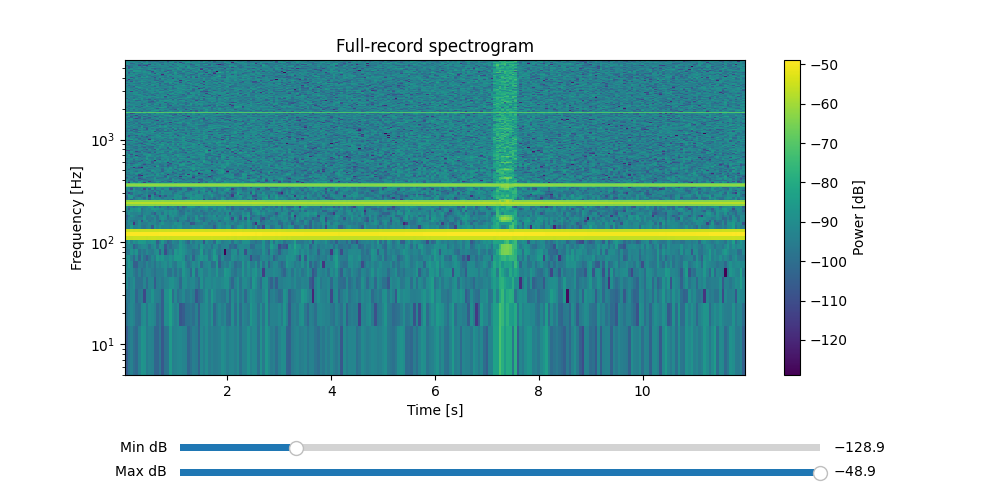

In [8]:
fig, ax = plot_spectrogram_dynamic_range(
    record,
    window_seconds=0.1,
    step_seconds=0.05,
    max_frequency_hz=6000,
    frequency_scale="log",
)
ax.set_title("Full-record spectrogram");

## 4. Shared Sliding-Window Feature Table

All detectors below use the same feature table. The windows match the v2 walkthrough: 0.20 seconds wide with a 0.025 second step. This gives hundreds of interpretable rows instead of high-dimensional raw waveform chunks.

In [9]:
window_config = SlidingWindowConfig(
    window_seconds=0.20,
    step_seconds=0.025,
    frequency_bands=(
        FrequencyBand("rotating_40_500", 40.0, 500.0),
        FrequencyBand("resonance_1800_3200", 1800.0, 3200.0),
        FrequencyBand("broadband_3200_6000", 3200.0, 6000.0),
    ),
    frequency_window="hann",
    normalize_frequency_window_power=True,
)

features = sliding_window_features(record, window_config)
print(f"Feature rows: {len(features):,}")
print(f"Feature columns: {len(features.columns):,}")
features.head()

Feature rows: 473
Feature columns: 25


,record_name,label,window_start_seconds,window_end_seconds,window_center_seconds,window_n_samples,frequency_window,mean,std,min,...,skewness,kurtosis,dominant_frequency_hz,spectral_centroid_hz,spectral_bandwidth_hz,spectral_rolloff_85_hz,spectral_flatness,band_energy_rotating_40_500,band_energy_resonance_1800_3200,band_energy_broadband_3200_6000
0,vibration_anomaly_single_record,None,0.000,0.200,0.100,4000.0,hann,0.000003,0.014464,-0.035571,...,-0.530018,2.108628,120.0,3719.056983,3238.534563,7875.0,0.625872,0.000198,0.000005,0.000002
1,vibration_anomaly_single_record,None,0.025,0.225,0.125,4000.0,hann,0.000010,0.014495,-0.035571,...,-0.533799,2.117515,120.0,3733.984990,3261.070247,7955.0,0.625007,0.000199,0.000005,0.000002
2,vibration_anomaly_single_record,None,0.050,0.250,0.150,4000.0,hann,-0.000004,0.014549,-0.035571,...,-0.531258,2.114220,120.0,3738.672065,3260.597807,7960.0,0.619443,0.000201,0.000005,0.000002
3,vibration_anomaly_single_record,None,0.075,0.275,0.175,4000.0,hann,0.000002,0.014584,-0.035879,...,-0.534853,2.114959,120.0,3738.269428,3252.640222,7965.0,0.618599,0.000204,0.000006,0.000002
4,vibration_anomaly_single_record,None,0.100,0.300,0.200,4000.0,hann,-0.000003,0.014591,-0.035879,...,-0.539817,2.122344,120.0,3702.785234,3229.328881,7930.0,0.623928,0.000205,0.000006,0.000002


In [10]:
model_feature_columns = [
    column
    for column in features.select_dtypes(include=[np.number]).columns
    if column
    not in {
        "window_start_seconds",
        "window_end_seconds",
        "window_center_seconds",
        "window_n_samples",
        "sampling_rate_hz",
        "n_samples",
        "duration_seconds",
    }
]

model_feature_columns

['mean',
 'std',
 'min',
 'max',
 'peak_to_peak',
 'rms',
 'crest_factor',
 'zero_crossing_rate',
 'skewness',
 'kurtosis',
 'dominant_frequency_hz',
 'spectral_centroid_hz',
 'spectral_bandwidth_hz',
 'spectral_rolloff_85_hz',
 'spectral_flatness',
 'band_energy_rotating_40_500',
 'band_energy_resonance_1800_3200',
 'band_energy_broadband_3200_6000']

## 5. Reference Hand-Built Score

This mirrors the v2 walkthrough: a transparent score from a few physically interpretable features. It is useful as a sanity check against generic detectors.

In [46]:
def robust_positive_z(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce")
    median = values.median()
    mad = (values - median).abs().median()
    if not np.isfinite(mad) or mad == 0.0:
        return pd.Series(np.zeros(len(values)), index=values.index)
    z = 0.6745 * (values - median) / mad
    return z.clip(lower=0.0)

reference_score_columns = [
    "rms",
    "crest_factor",
    "kurtosis",
    "band_energy_resonance_1800_3200",
    "band_energy_broadband_3200_6000",
]

reference = features[[
    "record_name",
    "label",
    "window_start_seconds",
    "window_end_seconds",
    "window_center_seconds",
]].copy()
reference["row_index"] = features.index
reference["anomaly_score"] = sum(
    robust_positive_z(features[column]) for column in reference_score_columns
)
reference["anomaly_rank"] = reference["anomaly_score"].rank(method="first", ascending=False).astype(int)
reference.sort_values("anomaly_score", ascending=False).head(10)

,record_name,label,window_start_seconds,window_end_seconds,window_center_seconds,row_index,anomaly_score,anomaly_rank
289,vibration_anomaly_single_record,None,7.225,7.425,7.325,289,189.634181,1
290,vibration_anomaly_single_record,None,7.250,7.450,7.350,290,189.410227,2
287,vibration_anomaly_single_record,None,7.175,7.375,7.275,287,187.794808,3
288,vibration_anomaly_single_record,None,7.200,7.400,7.300,288,187.559739,4
291,vibration_anomaly_single_record,None,7.275,7.475,7.375,291,185.530273,5
286,vibration_anomaly_single_record,None,7.150,7.350,7.250,286,181.750146,6
292,vibration_anomaly_single_record,None,7.300,7.500,7.400,292,176.713650,7
285,vibration_anomaly_single_record,None,7.125,7.325,7.225,285,174.896825,8
293,vibration_anomaly_single_record,None,7.325,7.525,7.425,293,167.378578,9
294,vibration_anomaly_single_record,None,7.350,7.550,7.450,294,164.727000,10


## 6. Generic Feature-Based Detectors

These methods return exploratory anomaly scores over windows. Robust Mahalanobis is used because candidate anomalies may contaminate ordinary mean and covariance estimates. It is fitted on a compact pair of non-degenerate features to avoid redundant near-deterministic feature relationships during covariance estimation.

In [47]:
evaluations = {
    "reference_robust_z": reference,
    "robust_positive_z": run_robust_z_score(features).predictions,
    "robust_mahalanobis_distance": run_robust_mahalanobis_distance(
        features,
        feature_columns=['rms', "kurtosis","crest_factor", "band_energy_broadband_3200_6000"],
        random_state=0,
    ).predictions,
    "isolation_forest": run_isolation_forest(features, contamination=0.03, random_state=0).predictions,
    "one_class_svm": run_one_class_svm(features, nu=0.03).predictions,
    "local_outlier_factor": run_local_outlier_factor(features, n_neighbors=10, contamination=0.03).predictions,
    "pca_reconstruction": run_pca_reconstruction(features, n_components=0.95).predictions,
    # DBSCAN is eps-sensitive and included only as an exploratory clustering diagnostic.
    "dbscan_exploratory": run_dbscan_outlier_scores(features, eps=1.5, min_samples=8).predictions,
}

summary_rows = []
for method, predictions in evaluations.items():
    top = predictions.sort_values("anomaly_score", ascending=False).head(5)
    for _, row in top.iterrows():
        summary_rows.append(
            {
                "method": method,
                "rank": int(row.get("anomaly_rank", np.nan)),
                "window_start_seconds": row["window_start_seconds"],
                "window_end_seconds": row["window_end_seconds"],
                "window_center_seconds": row["window_center_seconds"],
                "anomaly_score": row["anomaly_score"],
            }
        )

top_by_method = pd.DataFrame(summary_rows)
top_by_method

,method,rank,window_start_seconds,window_end_seconds,window_center_seconds,anomaly_score
0,reference_robust_z,1,7.225,7.425,7.325,189.634181
1,reference_robust_z,2,7.250,7.450,7.350,189.410227
2,reference_robust_z,3,7.175,7.375,7.275,187.794808
3,reference_robust_z,4,7.200,7.400,7.300,187.559739
4,reference_robust_z,5,7.275,7.475,7.375,185.530273
5,robust_positive_z,1,7.250,7.450,7.350,390.080570
6,robust_positive_z,2,7.275,7.475,7.375,387.569575
7,robust_positive_z,3,7.300,7.500,7.400,380.532814
8,robust_positive_z,4,7.225,7.425,7.325,380.319967
9,robust_positive_z,5,7.200,7.400,7.300,375.295097


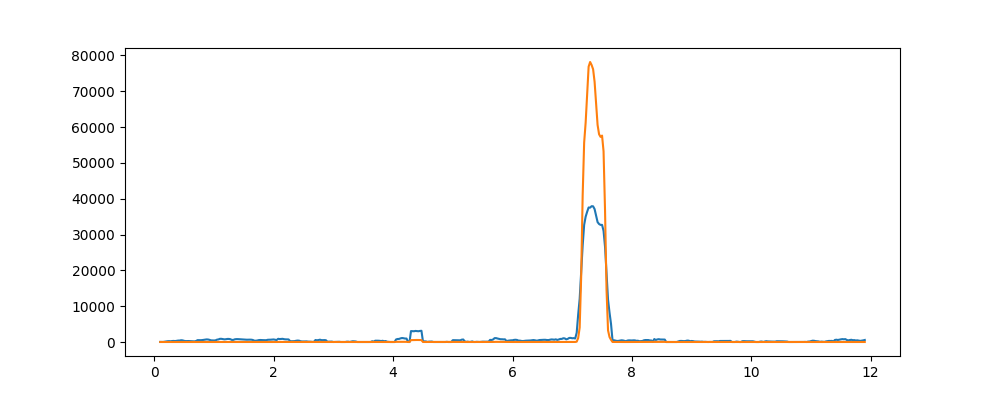

In [48]:
#evaluations["isolation_forest"].sort_values("anomaly_score", ascending=False).head(10)
plt.figure(figsize=(10, 4))
plt.plot(evaluations["reference_robust_z"]["window_center_seconds"], evaluations["reference_robust_z"]["anomaly_score"]*200)
plt.plot(evaluations["robust_mahalanobis_distance"]["window_center_seconds"], evaluations["robust_mahalanobis_distance"]["anomaly_score"])

In [14]:
def minmax_score(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce")
    low = values.min()
    high = values.max()
    if not np.isfinite(low) or not np.isfinite(high) or high == low:
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - low) / (high - low)

score_frame = features[["window_start_seconds", "window_end_seconds", "window_center_seconds"]].copy()
score_frame["row_index"] = features.index
rank_frame = score_frame.copy()

for method, predictions in evaluations.items():
    aligned = predictions[["row_index", "anomaly_score"]].copy()
    aligned[f"{method}_score"] = minmax_score(aligned["anomaly_score"])
    aligned[f"{method}_rank"] = aligned["anomaly_score"].rank(method="first", ascending=False)
    score_frame = score_frame.merge(
        aligned[["row_index", f"{method}_score"]],
        on="row_index",
        how="left",
    ).rename(columns={f"{method}_score": method})
    rank_frame = rank_frame.merge(
        aligned[["row_index", f"{method}_rank"]],
        on="row_index",
        how="left",
    ).rename(columns={f"{method}_rank": method})

score_columns = list(evaluations)
score_frame["consensus_score"] = score_frame[score_columns].mean(axis=1)
score_frame["consensus_rank"] = score_frame["consensus_score"].rank(method="first", ascending=False).astype(int)

consensus = score_frame.sort_values("consensus_score", ascending=False)
consensus.head(15)

,window_start_seconds,window_end_seconds,window_center_seconds,row_index,reference_robust_z,robust_positive_z,robust_mahalanobis_distance,isolation_forest,one_class_svm,local_outlier_factor,pca_reconstruction,dbscan_exploratory,consensus_score,consensus_rank
290,7.250,7.450,7.350,290,0.982085,1.000000,0.971781,0.986538,0.937315,0.018814,0.684760,1.000000,0.822662,1
291,7.275,7.475,7.375,291,0.955606,0.993549,0.926322,1.000000,0.846825,0.014204,0.583528,0.991582,0.788952,2
289,7.225,7.425,7.325,289,0.991332,0.974923,0.989893,0.981179,0.936958,0.014521,0.337847,0.968314,0.774371,3
292,7.300,7.500,7.400,292,0.905697,0.975470,0.847681,0.958564,0.809946,0.016071,0.649537,0.976391,0.767420,4
284,7.100,7.300,7.200,284,0.888260,0.785353,0.698496,0.958289,0.936867,0.021261,0.869947,0.938048,0.762065,5
285,7.125,7.325,7.225,285,0.936724,0.848491,0.770659,0.934629,0.935878,0.006650,0.707844,0.940805,0.760210,6
293,7.325,7.525,7.425,293,0.869111,0.942365,0.775614,0.928377,0.936637,0.013842,0.603042,0.943050,0.751505,7
286,7.150,7.350,7.250,286,0.977018,0.906852,0.880310,0.929680,0.936873,0.002986,0.364167,0.953196,0.743885,8
288,7.200,7.400,7.300,288,0.997473,0.962013,1.000000,0.924475,0.864989,0.014204,0.154180,0.955193,0.734066,9
287,7.175,7.375,7.275,287,1.000000,0.934601,0.977905,0.920580,0.935703,0.014258,0.135047,0.948409,0.733313,10


## 7. Score Timelines And Agreement

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
for method in score_columns:
    ax.plot(
        score_frame["window_center_seconds"],
        score_frame[method],
        linewidth=1.0,
        alpha=0.8,
        label=method,
    )
ax.plot(
    score_frame["window_center_seconds"],
    score_frame["consensus_score"],
    color="black",
    linewidth=2.0,
    label="consensus_score",
)
ax.set_title("Normalized anomaly scores by window")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Min-max normalized score")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", ncols=2)
fig.tight_layout();

In [16]:
agreement = score_frame[["window_start_seconds", "window_end_seconds", "window_center_seconds", "consensus_score", "consensus_rank"]].copy()
for method in score_columns:
    agreement[f"{method}_top_20"] = rank_frame[method] <= 20
agreement["top_20_votes"] = agreement[[f"{method}_top_20" for method in score_columns]].sum(axis=1)

agreement.sort_values(["top_20_votes", "consensus_score"], ascending=False).head(20)

,window_start_seconds,window_end_seconds,window_center_seconds,consensus_score,consensus_rank,reference_robust_z_top_20,robust_positive_z_top_20,robust_mahalanobis_distance_top_20,isolation_forest_top_20,one_class_svm_top_20,local_outlier_factor_top_20,pca_reconstruction_top_20,dbscan_exploratory_top_20,top_20_votes
290,7.250,7.450,7.350,0.822662,1,True,True,True,True,True,False,True,True,7
284,7.100,7.300,7.200,0.762065,5,True,True,True,True,True,False,True,True,7
293,7.325,7.525,7.425,0.751505,7,True,True,True,True,True,False,True,True,7
286,7.150,7.350,7.250,0.743885,8,True,True,True,True,True,False,True,True,7
283,7.075,7.275,7.175,0.709684,11,True,True,True,True,True,False,True,True,7
282,7.050,7.250,7.150,0.614298,17,True,True,True,True,True,False,True,True,7
299,7.475,7.675,7.575,0.588615,18,True,True,True,True,True,False,True,True,7
291,7.275,7.475,7.375,0.788952,2,True,True,True,True,False,False,True,True,6
289,7.225,7.425,7.325,0.774371,3,True,True,True,True,True,False,False,True,6
292,7.300,7.500,7.400,0.767420,4,True,True,True,True,False,False,True,True,6


## 8. Inspect The Top Consensus Region

The consensus window is still only a candidate. Inspect the raw waveform and localized time-frequency views before making any engineering claim.

In [17]:
top_consensus = consensus.iloc[0]
candidate_center = float(top_consensus["window_center_seconds"])
zoom_start = max(candidate_center - 0.6, 0.0)
zoom_duration = 1.2

print(
    "Top consensus candidate: "
    f"{top_consensus['window_start_seconds']:.3f} s to "
    f"{top_consensus['window_end_seconds']:.3f} s, "
    f"center {candidate_center:.3f} s"
)

fig, ax = plot_time_signal(
    record,
    start_seconds=zoom_start,
    duration_seconds=zoom_duration,
    max_points=8000,
)
ax.axvspan(
    float(top_consensus["window_start_seconds"]),
    float(top_consensus["window_end_seconds"]),
    color="tab:red",
    alpha=0.2,
    label="top consensus window",
)
ax.set_ylabel("Voltage [V]")
ax.set_title("Raw signal around top consensus candidate")
ax.legend(loc="best");

Top consensus candidate: 7.250 s to 7.450 s, center 7.350 s


In [18]:
start_index = int(round(zoom_start * record.sampling_rate_hz))
end_index = int(round((zoom_start + zoom_duration) * record.sampling_rate_hz))
end_index = min(end_index, record.n_samples)

zoom_record = SignalRecord(
    values=record.values[start_index:end_index],
    sampling_rate_hz=record.sampling_rate_hz,
    name=f"{record.name}_consensus_zoom",
    metadata={
        **record.metadata,
        "window_start_seconds": zoom_start,
        "window_end_seconds": end_index / record.sampling_rate_hz,
    },
)

fig, ax = plot_spectrogram_dynamic_range(
    zoom_record,
    window_seconds=0.05,
    step_seconds=0.0025,
    max_frequency_hz=6000,
    frequency_scale="log",
)
ax.set_title("Candidate-region spectrogram; time is relative to zoom window");

In [19]:
fig, ax = plot_wavelet_scalogram(
    zoom_record,
    min_frequency_hz=20.0,
    max_frequency_hz=6000.0,
    n_frequencies=128,
    frequency_scale="log",
)
ax.set_title("Candidate-region Morlet wavelet scalogram; time is relative to zoom window");

## 9. Interpretation Limits

This notebook compares feature-based unsupervised rankings on one unlabeled record. The strongest result is agreement about which windows deserve inspection.

Important limitations:

- There is only one record and no confirmed anomaly labels.
- Sliding windows overlap, so rows are not independent samples.
- Detector parameters such as contamination, `nu`, neighbor count, PCA variance, and DBSCAN `eps` affect rankings.
- DBSCAN is included as an exploratory clustering diagnostic only.
- These scores identify candidate windows, not faults. A real validation step would need labeled events, repeated acquisitions, or independent operating-condition metadata.